In [12]:
import torch
import math
import torch.nn as nn
import matplotlib.pyplot as plt
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"


def sine_dataset(T=200, batch=32):
    t = torch.linspace(0, 10, T)

    data = []
    target = []

    for _ in range(batch):
        phase = torch.rand(1) * 2 * math.pi

        x = torch.sin(t + phase)

        data.append(x[:-1].unsqueeze(-1))     # input u(t)
        target.append(x[1:].unsqueeze(-1))    # output z(t)

    return torch.stack(data), torch.stack(target)

In [ ]:
import torch
import torch.nn as nn

class PFC_CTRNN(nn.Module):
    def __init__(self, N=100, input_dim=1, dt=0.001, tau=0.01, noise_std=0.1):
        super().__init__()

        self.N = N
        self.dt = dt
        self.tau = tau
        self.noise_std = noise_std

        # recurrent connectivity J
        self.J = nn.Parameter(torch.randn(N, N) / (N ** 0.5))

        # input weights B
        self.B = nn.Parameter(torch.randn(N, input_dim) * 0.5)

        # bias current c^x
        self.c = nn.Parameter(torch.zeros(N))

        # readout weights w, c^z
        self.w = nn.Parameter(torch.randn(N, 1) * 0.1)
        self.cz = nn.Parameter(torch.zeros(1))

    def step(self, x, u):

        r = torch.tanh(x)

        # recurrent + input + bias
        dx = (-x + r @ self.J.T + u @ self.B.T + self.c) / self.tau

        # noise term (important for biological realism)
        noise = self.noise_std * torch.randn_like(x)

        x = x + self.dt * dx + noise * (self.dt ** 0.5) #euler update, delta t = 1ms

        return x, r

    def forward(self, u_seq, x0=None):

        T, B, _ = u_seq.shape

        x = torch.zeros(B, self.N, device=u_seq.device) if x0 is None else x0

        outputs = []

        for t in range(T):
            x, r = self.step(x, u_seq[t])

            z = r @ self.w + self.cz
            outputs.append(z)

        return torch.stack(outputs, dim=0)


In [25]:
model = PFC_CTRNN(N=100, input_dim=1)
opt = torch.optim.Adam(model.parameters(), lr=1e-3) #paper use hessian free optimization

for epoch in range(200):

    u, target = sine_dataset()

    u = u.transpose(0,1)         # (T,B,1)
    target = target.transpose(0,1)

    pred = model(u)

    loss = ((pred - target) ** 2).mean()

    opt.zero_grad()
    loss.backward()
    opt.step()

    if epoch % 20 == 0:
        print(epoch, loss.item())

0 0.7361158728599548
20 0.039235346019268036
40 0.0266824159771204
60 0.02103176712989807
80 0.021333839744329453
100 0.017352469265460968
120 0.016687067225575447
140 0.015198515728116035
160 0.01357941422611475
180 0.01372489519417286


In [26]:
print("pred shape:", pred.shape)
print("target shape:", target.shape)

pred shape: torch.Size([199, 32, 1])
target shape: torch.Size([199, 32, 1])


In [27]:
t = torch.linspace(0, 20, 200)
x_true = torch.sin(t)
x_seq = x_true[:-1].reshape(-1, 1, 1)   # (T, B, 1)
pred = model(x_seq)

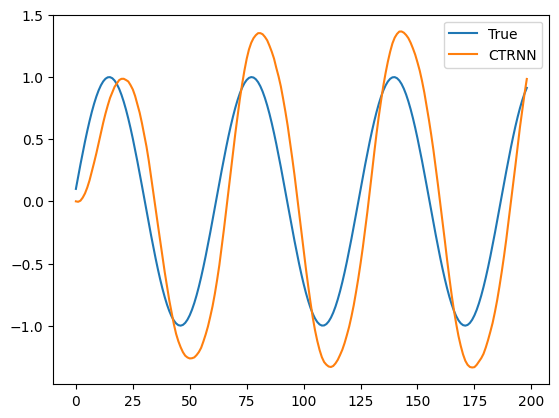

In [28]:
with torch.no_grad():
    plt.plot(x_true[1:].cpu())
    plt.plot(pred[:,0,0].cpu())
    plt.legend(["True", "CTRNN"])
    plt.show()